# Splits & runner tour

How the fairness protocol's machinery works: the stored splits in
`data/splits/`, the config-driven runner, and the append-only results log.

**Exploration only, never source of truth** (CLAUDE.md; groundwork §3).
⚠️ The demo run below writes to a **temporary directory** — `results/*.csv` are
append-only, git-tracked thesis logs; never point demo runs at them.


In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import json

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from data import available_datasets, load_dataset
from data.preprocessing import ANGLE_MAX, AngleScaler

# Chart chrome: the validated reference palette used across the project.
INK, INK2, MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, AXIS, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"
BLUE, AQUA, BLUE_DARK = "#2a78d6", "#1baf7a", "#184f95"
mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "axes.edgecolor": AXIS, "axes.labelcolor": INK2, "axes.titlecolor": INK,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.axisbelow": True,
    "xtick.color": MUTED, "ytick.color": MUTED, "text.color": INK,
    "font.family": "sans-serif", "figure.dpi": 110, "legend.frameon": False,
})
print("repo root:", ROOT)


repo root: /home/user/quantum_ml_vs_traditional_ml-comparison


## Anatomy of a stored splits file

Generated once by `data/make_splits.py`, committed forever: 5-fold stratified
CV × seeds 0–4 → 25 checksummed `(seed, fold)` index sets per dataset. Every
model in E1–E10 evaluates on exactly these indices.


In [2]:
payload = json.loads((ROOT / "data" / "splits" / "moons.json").read_text())
print("top-level keys :", list(payload))
print("dataset        :", payload["dataset"], "| seeds:", payload["seeds"],
      "| n_folds:", payload["n_folds"])
print("created (UTC)  :", payload["created_utc"], "| sklearn:", payload["sklearn_version"])

from data.make_splits import checksum_of
print("checksum valid :", checksum_of(payload["splits"]) == payload["checksum"])

X, y, _ = load_dataset("moons")
rows = [{"split_id": sid,
         "n_train": len(entry["train"]),
         "n_test": len(entry["test"]),
         "class-1 share (test)": round(float(y[np.array(entry["test"])].mean()), 3)}
        for sid, entry in payload["splits"].items()]
pd.DataFrame(rows).set_index("split_id").head(10)


top-level keys : ['dataset', 'created_utc', 'seeds', 'n_folds', 'sklearn_version', 'loader_meta', 'checksum', 'splits']
dataset        : moons | seeds: [0, 1, 2, 3, 4] | n_folds: 5
created (UTC)  : 2026-07-06T15:19:00+00:00 | sklearn: 1.9.0
checksum valid : True


,n_train,n_test,class-1 share (test)
split_id,,,
s0_f0,400,100,0.5
s0_f1,400,100,0.5
s0_f2,400,100,0.5
s0_f3,400,100,0.5
s0_f4,400,100,0.5
s1_f0,400,100,0.5
s1_f1,400,100,0.5
s1_f2,400,100,0.5
s1_f3,400,100,0.5


The stratification is visible above: every test fold carries the dataset's
class balance (0.5 for moons). Disjointness, coverage, and byte-exact
reproducibility are proven by `tests/test_splits.py` and
`python data/make_splits.py --all --verify`.

## Run an experiment — same code path as the CLI

`experiments/run.py` exposes `run(config, results_dir, splits_dir)`; the CLI is
a thin wrapper around it. One CSV row per (seed, fold).


In [3]:
import tempfile

from experiments.run import run as run_experiment

demo_dir = Path(tempfile.mkdtemp(prefix="qml_demo_results_"))  # NOT results/
csv_path = run_experiment(ROOT / "experiments" / "configs" / "e0_smoke.yaml",
                          results_dir=demo_dir)
df = pd.read_csv(csv_path)
df.head(3)


[e0_smoke] moons/logreg s0_f0: acc=0.900000 f1=0.900000
[e0_smoke] moons/logreg s0_f1: acc=0.850000 f1=0.851485
[e0_smoke] moons/logreg s0_f2: acc=0.830000 f1=0.834951
[e0_smoke] moons/logreg s0_f3: acc=0.810000 f1=0.808081
[e0_smoke] moons/logreg s0_f4: acc=0.880000 f1=0.877551
[e0_smoke] moons/logreg s1_f0: acc=0.870000 f1=0.865979
[e0_smoke] moons/logreg s1_f1: acc=0.820000 f1=0.816327
[e0_smoke] moons/logreg s1_f2: acc=0.840000 f1=0.843137
[e0_smoke] moons/logreg s1_f3: acc=0.830000 f1=0.834951
[e0_smoke] moons/logreg s1_f4: acc=0.910000 f1=0.910891
[e0_smoke] moons/logreg s2_f0: acc=0.850000 f1=0.848485
[e0_smoke] moons/logreg s2_f1: acc=0.800000 f1=0.800000
[e0_smoke] moons/logreg s2_f2: acc=0.850000 f1=0.851485
[e0_smoke] moons/logreg s2_f3: acc=0.880000 f1=0.884615
[e0_smoke] moons/logreg s2_f4: acc=0.900000 f1=0.895833
[e0_smoke] moons/logreg s3_f0: acc=0.880000 f1=0.877551
[e0_smoke] moons/logreg s3_f1: acc=0.830000 f1=0.841121
[e0_smoke] moons/logreg s3_f2: acc=0.880000 f1=0

[e0_smoke] moons/logreg s4_f0: acc=0.890000 f1=0.893204
[e0_smoke] moons/logreg s4_f1: acc=0.780000 f1=0.780000
[e0_smoke] moons/logreg s4_f2: acc=0.850000 f1=0.851485
[e0_smoke] moons/logreg s4_f3: acc=0.920000 f1=0.920000
[e0_smoke] moons/logreg s4_f4: acc=0.840000 f1=0.833333
[e0_smoke] appended 25 rows -> /tmp/qml_demo_results_pj0vt6us/e0_smoke.csv


,run_id,timestamp_utc,experiment,dataset,model,config_hash,seed,split_id,regime,n_train,n_test,n_features,n_params,accuracy,balanced_accuracy,f1,roc_auc,train_time_s,eval_time_s,git_commit
0,2bef50b3b364,2026-07-06T16:04:21+00:00,e0_smoke,moons,logreg,83a86d69f9,0,s0_f0,classical,400,100,2,3,0.90,0.90,0.900000,0.9740,0.0058,0.0006,b5ca872
1,cf18585fdaa2,2026-07-06T16:04:21+00:00,e0_smoke,moons,logreg,83a86d69f9,0,s0_f1,classical,400,100,2,3,0.85,0.85,0.851485,0.9456,0.0049,0.0005,b5ca872
2,9c2a5cc9351a,2026-07-06T16:04:21+00:00,e0_smoke,moons,logreg,83a86d69f9,0,s0_f2,classical,400,100,2,3,0.83,0.83,0.834951,0.9596,0.0040,0.0005,b5ca872


In [4]:
print(f"overall: {df['accuracy'].mean():.4f} ± {df['accuracy'].std(ddof=0):.4f} "
      f"over {len(df)} (seed, fold) evaluations")
df.groupby("seed")["accuracy"].agg(["mean", "std", "min", "max"]).round(4)


overall: 0.8564 ± 0.0345 over 25 (seed, fold) evaluations


,mean,std,min,max
seed,,,,
0,0.854,0.0365,0.81,0.90
1,0.854,0.0365,0.82,0.91
2,0.856,0.0378,0.80,0.90
3,0.862,0.0217,0.83,0.88
4,0.856,0.0532,0.78,0.92


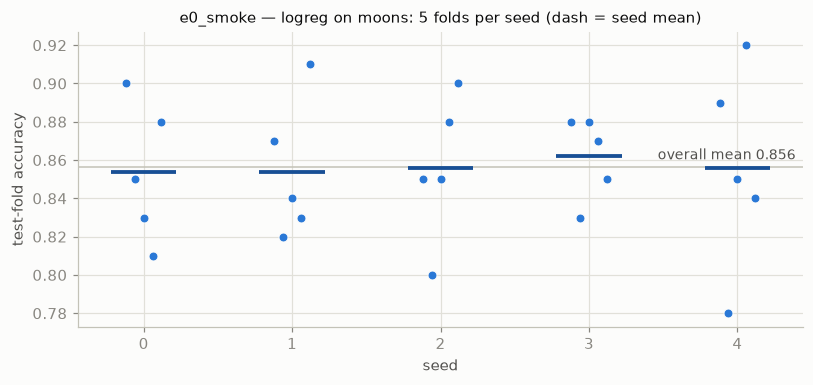

In [5]:
fig, ax = plt.subplots(figsize=(7.5, 3.6))
for seed, grp in df.groupby("seed"):
    x = np.full(len(grp), float(seed)) + np.linspace(-0.12, 0.12, len(grp))
    ax.scatter(x, grp["accuracy"], s=34, c=BLUE,
               edgecolors=SURFACE, linewidths=0.6, zorder=3)
    ax.hlines(grp["accuracy"].mean(), seed - 0.22, seed + 0.22,
              color=BLUE_DARK, linewidth=2.5, zorder=4)
overall = df["accuracy"].mean()
ax.axhline(overall, color=AXIS, linewidth=1)
ax.annotate(f"overall mean {overall:.3f}", xy=(0.99, overall),
            xycoords=("axes fraction", "data"),
            textcoords="offset points", xytext=(0, 5),
            ha="right", fontsize=9, color=INK2)
ax.set_xticks(range(5))
ax.set_xlabel("seed")
ax.set_ylabel("test-fold accuracy")
ax.set_title("e0_smoke — logreg on moons: 5 folds per seed (dash = seed mean)",
             fontsize=10)
plt.tight_layout()


## Determinism

Same config + same stored splits + per-seed seeding ⇒ identical metrics, every
time, in any process. The committed `results/e0_smoke.csv` was produced by the
CLI; this notebook's fresh run must match it exactly:


In [6]:
committed = pd.read_csv(ROOT / "results" / "e0_smoke.csv")
print("demo run reproduces the committed results exactly:",
      list(df["accuracy"]) == list(committed["accuracy"][:25]))


demo run reproduces the committed results exactly: True


## Doing real runs

```bash
python experiments/run.py --config experiments/configs/e0_smoke.yaml
```

- Rows **append** to `results/<experiment>.csv` — never overwritten; a foreign
  header aborts the run.
- The 25 rows of one locked config share one `config_hash` — that is how
  analysis scripts group runs (see `results/README.md`).
- Simulation regimes (`exact`, `shots`, `noisy`, `hardware`, `classical`) are
  never mixed in one analysis table (groundwork §8).
